# Make Segments

## Clean dataset

In [ ]:
from fn.pipeline import *
preprocess_and_save_dataset(
    r"data\machine_translation_docs_info.json",
    r"data\translation_dataset.pkl"
)
preprocess_and_save_dataset(
    r"data\machine_learning_docs_info.json",
    r"data\learning_dataset.pkl"
)

Preprocessing dataset...
Saved processed dataset to data\translation_dataset.pkl
Preprocessing dataset...
Saved processed dataset to data\learning_dataset.pkl



=== TRANSLATION ===


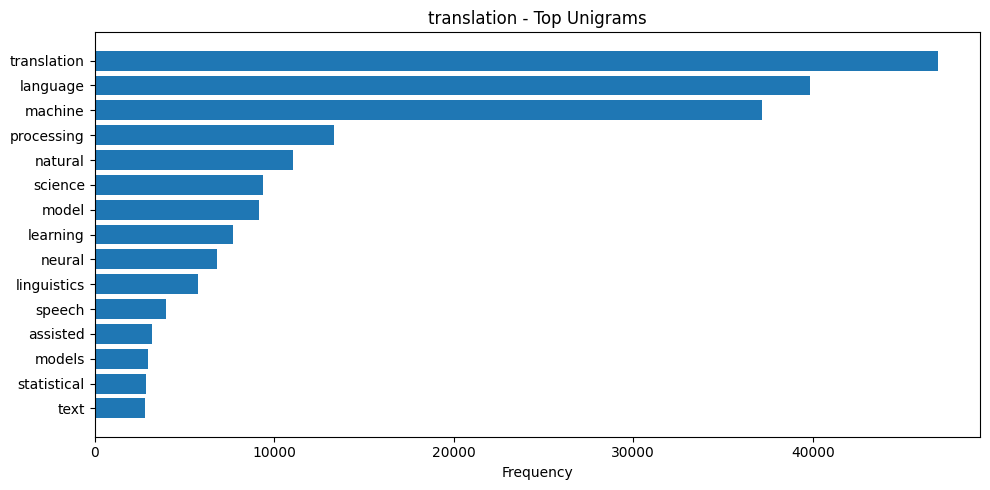

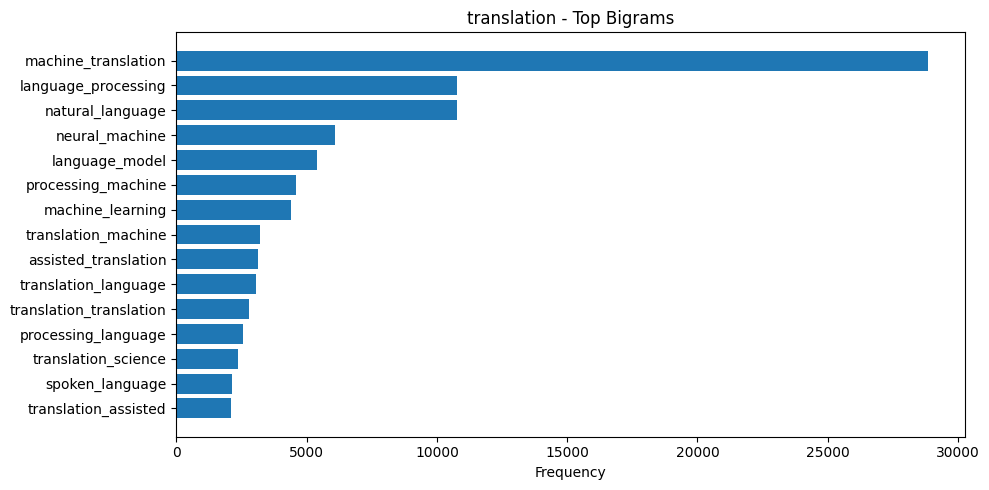

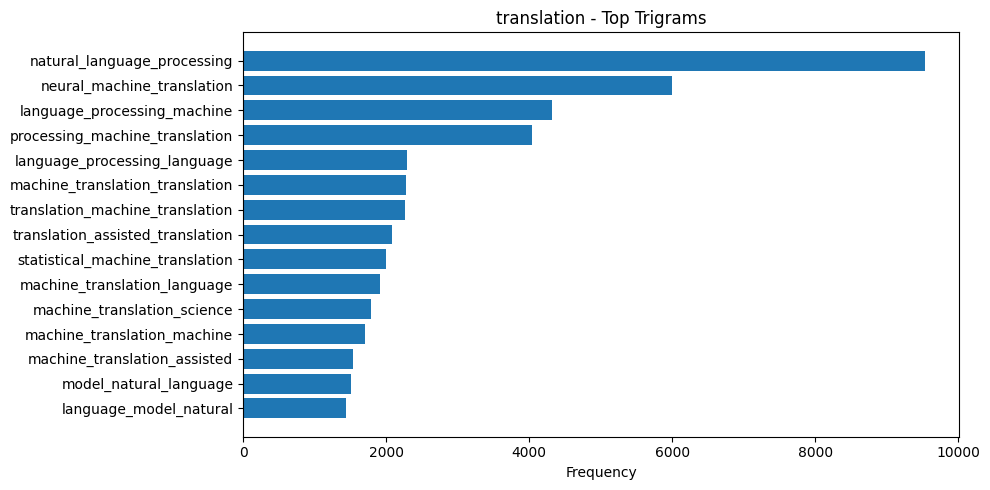

In [1]:
import pickle
from collections import Counter
import matplotlib.pyplot as plt


def extract_ngrams(tokens_list):
    unigram = Counter()
    bigram = Counter()
    trigram = Counter()

    for tokens in tokens_list:
        unigram.update(tokens)

        bigram.update([
            "_".join(tokens[i:i+2])
            for i in range(len(tokens)-1)
        ])

        trigram.update([
            "_".join(tokens[i:i+3])
            for i in range(len(tokens)-2)
        ])

    return unigram, bigram, trigram


def plot_top(counter, title, top_n=15):
    most_common = counter.most_common(top_n)

    words = [w for w, _ in most_common]
    counts = [c for _, c in most_common]

    plt.figure(figsize=(10, 5))
    plt.barh(words[::-1], counts[::-1])
    plt.title(title)
    plt.xlabel("Frequency")
    plt.tight_layout()
    plt.show()


def visualize_dataset(dataset_path, name="dataset"):
    with open(dataset_path, "rb") as f:
        year_groups = pickle.load(f)

    # flatten tokens
    all_tokens = []
    for docs in year_groups.values():
        for doc in docs:
            all_tokens.append(doc["tokens"])

    unigram, bigram, trigram = extract_ngrams(all_tokens)

    print(f"\n=== {name.upper()} ===")

    plot_top(unigram, f"{name} - Top Unigrams")
    plot_top(bigram, f"{name} - Top Bigrams")
    plot_top(trigram, f"{name} - Top Trigrams")

visualize_dataset(r"data\translation_dataset.pkl", name="translation")



=== LEARNING ===


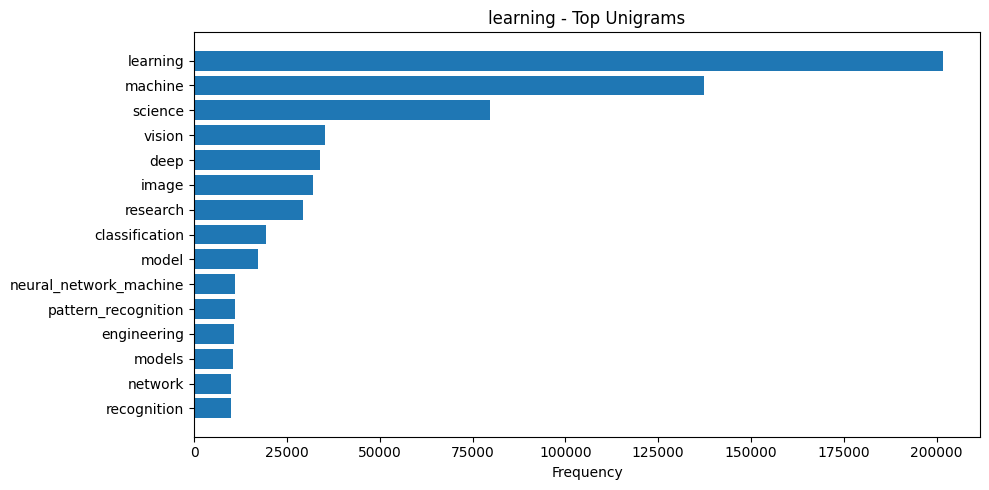

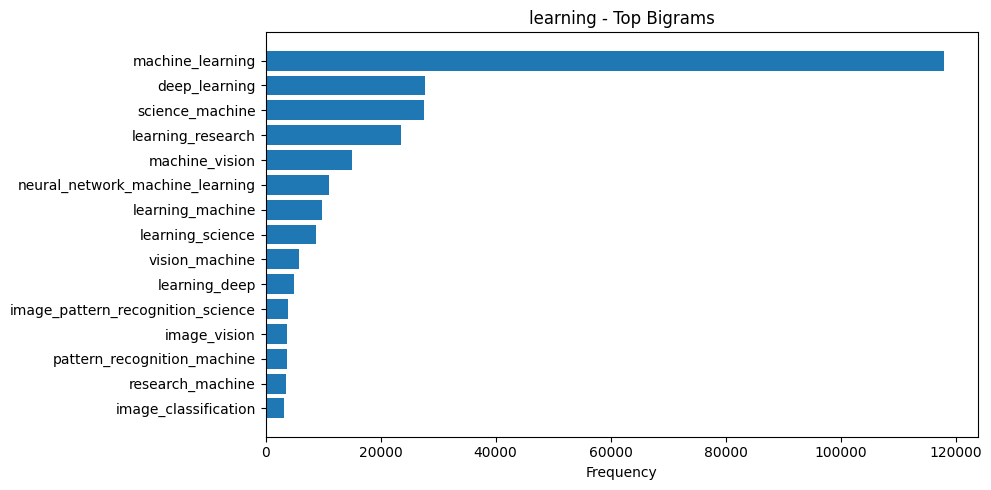

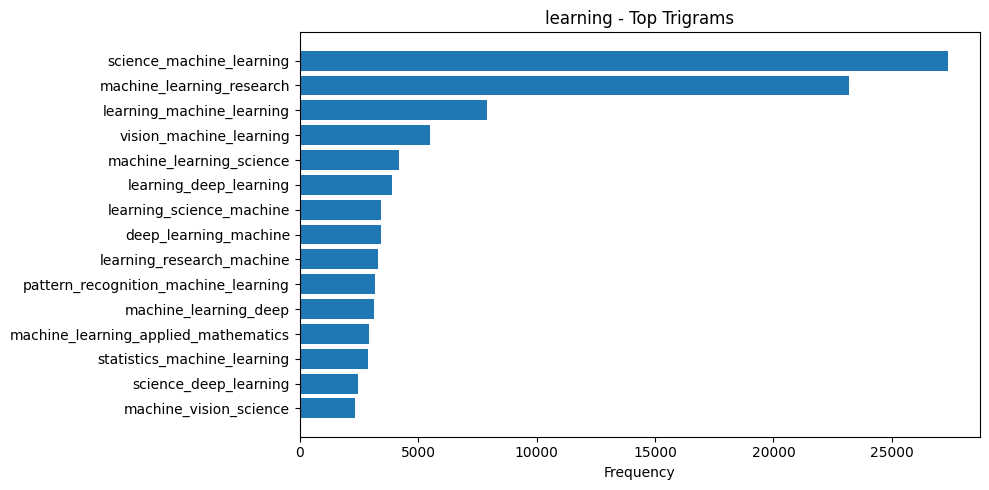

In [2]:
visualize_dataset(r"data\learning_dataset.pkl", name="learning")

## Train DMR Models

In [ ]:
from fn.pipeline import train_dmr_model
train_dmr_model(
    r"data\translation_dataset.pkl",
    r"models\trans_dmr.bin",
    k_topics=25,
    iterations=1900,
    log_filename="mt_log.txt"    
)


Training DMR model...
Iter 10: LL per word = -8.520750
Iter 20: LL per word = -8.083030
Iter 30: LL per word = -7.888352
Iter 40: LL per word = -7.784087
Iter 50: LL per word = -7.713149
Iter 60: LL per word = -7.670280
Iter 70: LL per word = -7.629832
Iter 80: LL per word = -7.604336
Iter 90: LL per word = -7.584376
Iter 100: LL per word = -7.568858
Iter 110: LL per word = -7.555714
Iter 120: LL per word = -7.545139
Iter 130: LL per word = -7.535565
Iter 140: LL per word = -7.526476
Iter 150: LL per word = -7.519161
Iter 160: LL per word = -7.511938
Iter 170: LL per word = -7.507680
Iter 180: LL per word = -7.496278
Iter 190: LL per word = -7.495483
Iter 200: LL per word = -7.486834
Iter 210: LL per word = -7.485036
Iter 220: LL per word = -7.481542
Iter 230: LL per word = -7.478521
Iter 240: LL per word = -7.474542
Iter 250: LL per word = -7.473172
Iter 260: LL per word = -7.469154
Iter 270: LL per word = -7.469019
Iter 280: LL per word = -7.465186
Iter 290: LL per word = -7.463736
I

In [ ]:
train_dmr_model(
    r"data\learning_dataset.pkl",
    r"models\learning_dmr.bin",
    k=30,
    iterations=2000,
    log_filename = "ml_log.txt"
)

Training DMR model...
Iter 10: LL per word = -9.356830893921316
Iter 20: LL per word = -8.706177955100975
Iter 30: LL per word = -8.457948318055138
Iter 40: LL per word = -8.331217242318191
Iter 50: LL per word = -8.252026655510953
Iter 60: LL per word = -8.196396176966813
Iter 70: LL per word = -8.158485386357986
Iter 80: LL per word = -8.129856508279289
Iter 90: LL per word = -8.107214843510258
Iter 100: LL per word = -8.091139921082004
Iter 110: LL per word = -8.079615757492993
Iter 120: LL per word = -8.065464147623123
Iter 130: LL per word = -8.055717917021397
Iter 140: LL per word = -8.047301184401292
Iter 150: LL per word = -8.03995658023991
Iter 160: LL per word = -8.03268978926262
Iter 170: LL per word = -8.029557807460876
Iter 180: LL per word = -8.022907227713587
Iter 190: LL per word = -8.019082247504095
Iter 200: LL per word = -8.015881719439683
Iter 210: LL per word = -8.01298880253816
Iter 220: LL per word = -8.009747805359742
Iter 230: LL per word = -8.00729557464174
It

## Elbow Method Visualization

Running lambda = 0.00
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.05
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.10
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.15
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.20
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.25
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.30
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.35
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.40
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.45
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.50
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.55
Extracting topic distributions...
Running segmentation DP...
Runn

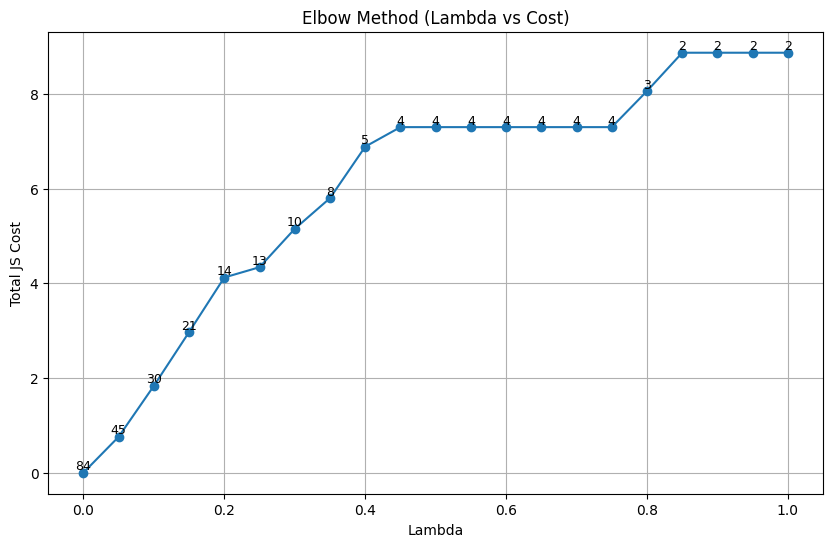

In [5]:
from fn.utils import sweep_lambda, plot_elbow
dataset_path = r"data\translation_dataset.pkl"
model_path = r"models\trans_dmr.bin"

lambdas, costs, segments = sweep_lambda(dataset_path, model_path)

plot_elbow(lambdas, costs, segments)

Running lambda = 0.00
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.05
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.10
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.15
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.20
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.25
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.30
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.35
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.40
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.45
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.50
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.55
Extracting topic distributions...
Running segmentation DP...
Runn

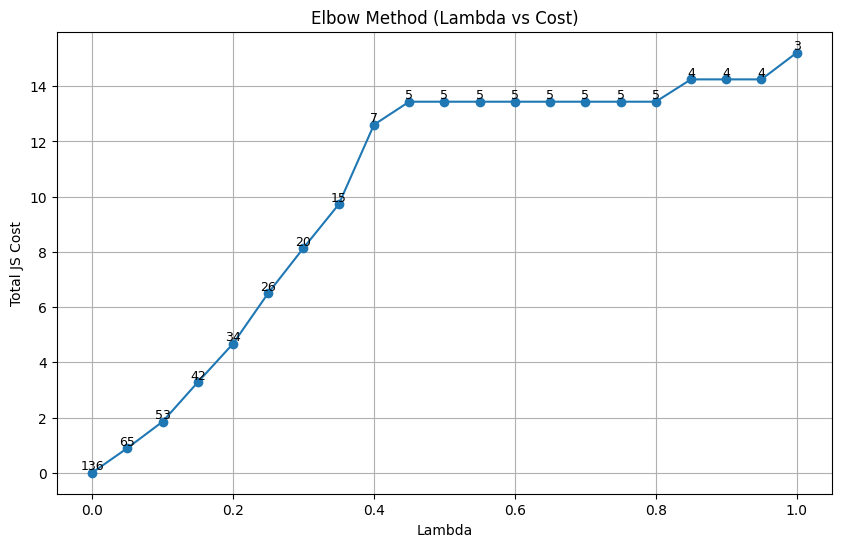

In [6]:
from fn.utils import sweep_lambda, plot_elbow
dataset_path = r"data\learning_dataset.pkl"
model_path = r"models\learning_dmr.bin"
lambdas, costs, segments = sweep_lambda(dataset_path, model_path)

plot_elbow(lambdas, costs, segments)


In [13]:
import tomotopy as tp


def print_dmr_topics(model, top_n=10):
    for topic_id in range(model.k):
        words = model.get_topic_words(topic_id, top_n=top_n)

        topic_str = ", ".join([
            f"{w}:{p:.3f}"   # 3 chữ số thập phân
            for w, p in words
        ])

        print(f"Topic {topic_id:02d}: {topic_str}")


model = tp.DMRModel.load("models/trans_dmr.bin")

print_dmr_topics(model, top_n=10)

Topic 00: language:0.122, model:0.043, multilingual:0.032, natural:0.028, processing:0.022, models:0.022, languages:0.015, multilingualism:0.015, large:0.014, machine:0.013
Topic 01: language:0.076, machine:0.052, processing:0.047, text:0.031, recognition:0.030, natural:0.028, learning:0.021, text_mining:0.020, science:0.019, detection:0.013
Topic 02: machine:0.016, linguistics:0.012, research:0.010, university:0.009, papers:0.008, acl:0.008, year:0.008, conference:0.008, corpus_linguistics:0.007, information:0.007
Topic 03: translation:0.284, language:0.063, machine:0.050, multimodal:0.043, specialized:0.040, linguistics:0.039, speech:0.017, comparative_literature:0.017, assisted:0.013, interpretation:0.012
Topic 04: machine:0.120, science:0.044, translation:0.029, engineering:0.020, human:0.013, applied_mathematics:0.013, medical:0.011, scp_scp:0.010, machines:0.010, human_interaction:0.010
Topic 05: translation:0.020, different:0.007, use:0.006, information:0.006, proposed:0.005, ta

## Choose lambda and postprocess segments

### Machine Translation

In [8]:
import os
import pandas as pd

from fn.pipeline import build_timeline_from_model
from fn.utils import segments_to_dataframe  # hàm bạn vừa sửa


def run_timeline_and_save():
    dataset_path = r"data\translation_dataset.pkl"
    model_path = r"models\trans_dmr.bin"

    print("Running timeline model...")

    result = build_timeline_from_model(
        dataset_path=dataset_path,
        model_path=model_path,
        lambda_penalty=0.15,
        k_topics=25
    )

    print("Converting to dataframe...")

    df = segments_to_dataframe(result)

    output_path = r"data\timeline_segments.csv"

    print("Saving to:", output_path)
    df.to_csv(output_path, index=False, encoding="utf-8")

    print("Done. Rows:", len(df))

    return df

run_timeline_and_save()

Running timeline model...
Extracting topic distributions...
Running segmentation DP...
Converting to dataframe...
Saving to: data\timeline_segments.csv
Done. Rows: 21


,start_year,end_year,period,num_docs,topic,topic_certainty
0,1819,1852,2,2,24,0.620014
1,1899,1899,1,1,20,0.441322
2,1933,1933,1,2,19,0.820761
3,1941,1941,1,2,24,0.955770
4,1942,1942,1,1,1,0.737336
5,1943,1943,1,2,19,0.423626
6,1947,1947,1,1,19,0.653518
7,1949,1949,1,1,22,0.272525
8,1950,1950,1,1,1,0.405583
9,1951,1951,1,3,3,0.330358


In [ ]:
import os
import pandas as pd

from fn.pipeline import build_timeline_from_model
from fn.utils import segments_to_dataframe  # hàm bạn vừa sửa


def run_timeline_and_save():
    dataset_path = r"data\learning_dataset.pkl"
    model_path = r"models\learning_dmr.bin"

    print("Running timeline model...")

    result = build_timeline_from_model(
        dataset_path=dataset_path,
        model_path=model_path,
        lambda_penalty=0.15,
        k_topics=25
    )

    print("Converting to dataframe...")

    df = segments_to_dataframe(result)

    output_path = r"data\timeline_segments.csv"

    print("Saving to:", output_path)
    df.to_csv(output_path, index=False, encoding="utf-8")

    print("Done. Rows:", len(df))

    return df

run_timeline_and_save()

Running timeline model...
Extracting topic distributions...
Running segmentation DP...
Converting to dataframe...
Saving to: data\timeline_segments.csv
Done. Rows: 25


,start_year,end_year,period,num_docs,topic,topic_certainty
0,1744,1744,1,1,11,0.572497
1,1801,1801,1,1,19,0.734378
2,1819,1819,1,1,14,0.312567
3,1842,1842,1,1,13,0.507696
4,1852,1852,1,1,14,0.461196
5,1856,1856,1,1,19,0.498582
6,1859,1859,1,1,11,0.348567
7,1865,1886,2,3,4,0.391006
8,1888,1891,2,2,13,0.504776
9,1892,1895,3,4,4,0.267525
